#### This notebook adds to the insitu dataset (profiles) the surface information from AVISO ADT and Glorys (at depth 0)

In [1]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import dask as da
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import tqdm
import cmocean.cm as cmo
from pathlib import Path
import datetime
from calendar import monthrange

In [2]:
out_path = f'../data_for_lstm/var_depths_data_for_LSTM_A1.nc'

Choose glorys monthly or daily here

In [3]:
glorys_dir_daily = Path('/media/nicolas/DATOS/Reanalysis/GLORYS_daily_arctic_ST_2010_2024')

in_situ_dir = '/home/nicolas/SACO/FRESH-CARE/Data_in_situ/Dataset_16_Li/data_for_lstm/'
in_situ_file = 'lstm_training_profiles_all_depths_2011_2021.nc'
in_situ_path = os.path.join(in_situ_dir, in_situ_file)

ADT_dir = '/home/nicolas/SACO/FRESH-CARE/Data_satellite/AVISO/non_regridded_north_pole_1px/'
ADT_file = '*/*.nc'
ADT_path = os.path.join(ADT_dir, ADT_file)

--------------------------------
--------------------------------
OPEN ADT DATA

In [4]:
# ADT and GLORYS are opened month-by-month below — no global open needed

-------------------------------
-------------------------------
OPEN IN SITU DATA

(ADT is now from aviso and SST+SSS from reanalysis (Glorys) )

In [5]:
ds_insitu = xr.open_mfdataset(in_situ_path)
ds_insitu.compute()

<xarray.Dataset> Size: 934MB
Dimensions:            (profile: 188366, depth: 102)
Coordinates:
  * profile            (profile) int64 2MB 0 1 2 3 ... 188363 188364 188365
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/14)
    LATITUDE           (profile) float64 2MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 2MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 2MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 154MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 154MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 154MB 0.0 0.0 10.11 ... 0.0 0.0
    ...                 ...
    PSAL_augs          (profile, depth) float64 154MB 1.0 1.0 0.0 ... -1.0 -1.0
    TEMP_aug_fraction  (profile) float32 753kB 0.5122 0.1818 ... 0.4348 0.2162
    PSAL_aug_fraction  (profile) float32 753kB 0.5122 0.1818 ... 0.4348 0.2162
    lstm_training_QC   (profile) float64 2MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    X_EASE             (profile) float64 2MB -6.494e+05 2.643e+05 ... -4.477e+05
    Y_EASE             (profile) float64 2MB 1.122e+06 -1.324e+06 ... -2.104e+06
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

---
---

### Match up: push nearest surface data into in situ coordinates

In [6]:
ds_insitu['TIME'].sizes

Frozen({'profile': 188366})

In [7]:
# 5x5 spatial window offsets, sorted by distance from center
OFFSETS_5X5 = [
    (1, 0), (-1, 0), (0, 1), (0, -1),
    (1, 1), (1, -1), (-1, 1), (-1, -1),
    (2, 0), (-2, 0), (0, 2), (0, -2),
    (2, 1), (2, -1), (-2, 1), (-2, -1), (1, 2), (1, -2), (-1, 2), (-1, -2),
    (2, 2), (2, -2), (-2, 2), (-2, -2)
]


In [20]:
def fix_nans_in_open_slice(result_values, nan_indices, open_da, dim1, dim2, coord1_vals, coord2_vals):
    """
    Fix NaN entries in result_values using a 5x5 window search on an already-open 2D DataArray.

    open_da      : xr.DataArray with dims (dim1, dim2), loaded for a single time step
    nan_indices  : global indices into result_values that need fixing
    coord1_vals  : per-profile values for dim1 (length = total profiles)
    coord2_vals  : per-profile values for dim2
    """
    grid1 = open_da.coords[dim1].values
    grid2 = open_da.coords[dim2].values
    fixed = still_nan = 0
    for idx in nan_indices:
        i1 = np.argmin(np.abs(grid1 - coord1_vals[idx]))
        i2 = np.argmin(np.abs(grid2 - coord2_vals[idx]))
        found = False
        for d1, d2 in OFFSETS_5X5:
            ni1, ni2 = i1 + d1, i2 + d2
            if 0 <= ni1 < len(grid1) and 0 <= ni2 < len(grid2):
                val = float(open_da.isel({dim1: ni1, dim2: ni2}).values)
                if not np.isnan(val):
                    result_values[idx] = val
                    found = True
                    fixed += 1
                    break
        if not found:
            still_nan += 1
    return fixed, still_nan

# ---- ADT monthly matchup with inline NaN fix ----
ADT_base = Path(ADT_dir)
times_pd_adt = pd.DatetimeIndex(ds_insitu['TIME'].values)
year_months_adt = sorted(set(zip(times_pd_adt.year, times_pd_adt.month)))

nearest_ADT_values = np.full(len(ds_insitu.profile), np.nan)
ease_x = ds_insitu['X_EASE'].values
ease_y = ds_insitu['Y_EASE'].values

total_adt_fixed = total_adt_still = 0

import warnings
for year, month in tqdm.tqdm(year_months_adt, desc='Monthly ADT matchup'):
    month_mask = (times_pd_adt.year == year) & (times_pd_adt.month == month)
    month_indices = np.where(month_mask)[0]
    if len(month_indices) == 0:
        continue

    ds_insitu_month = ds_insitu.isel(profile=month_indices)

    _, n_days = monthrange(year, month)
    start_date = datetime.date(year, month, 1) - datetime.timedelta(days=4)
    end_date   = datetime.date(year, month, n_days) + datetime.timedelta(days=4)

    date_list = []
    d = start_date
    while d <= end_date:
        date_list.append(d)
        d += datetime.timedelta(days=1)

    adt_files_month = []
    for d in date_list:
        year_dir = ADT_base / f'{d.year:04d}'
        matched = sorted(year_dir.glob(f'*{d.strftime("%Y%m%d")}*.nc'))
        adt_files_month.extend(matched)

    if len(adt_files_month) == 0:
        print(f"Warning: No ADT files found for {year}-{month:02d}, skipping")
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ds_adt_month = xr.open_mfdataset(adt_files_month, data_vars='all')

    adt_month = ds_adt_month.adt.interp(
        coords={'time':   ds_insitu_month['TIME'],
                'y_ease': ds_insitu_month['Y_EASE'],
                'x_ease': ds_insitu_month['X_EASE']},
        method='linear'
    ).compute()

    nearest_ADT_values[month_indices] = adt_month.values

    nan_local = np.where(np.isnan(adt_month.values))[0]
    if len(nan_local) > 0:
        global_nan_idx = month_indices[nan_local]
        time_grid = ds_adt_month.adt.coords['time'].values
        insitu_times = ds_insitu['TIME'].values
        time_groups = {}
        for idx in global_nan_idx:
            t_idx = int(np.argmin(np.abs(time_grid - insitu_times[idx])))
            time_groups.setdefault(t_idx, []).append(idx)

        for t_idx, idxs in time_groups.items():
            slice_2d = ds_adt_month.adt.isel(time=t_idx).compute()
            f, s = fix_nans_in_open_slice(
                nearest_ADT_values, idxs, slice_2d,
                'y_ease', 'x_ease', ease_y, ease_x
            )
            total_adt_fixed += f
            total_adt_still += s

    ds_adt_month.close()

nearest_ADT = xr.DataArray(nearest_ADT_values, dims=['profile'])
n_total_adt = len(nearest_ADT_values)
n_initial_nan_adt = total_adt_fixed + total_adt_still
print(f"ADT matchup done. "
      f"Initially missing: {n_initial_nan_adt/n_total_adt*100:.1f}% | "
      f"Recovered by window: {total_adt_fixed/n_total_adt*100:.1f}% | "
      f"Still NaN: {np.isnan(nearest_ADT_values).sum()/n_total_adt*100:.1f}%")


Monthly ADT matchup: 100%|██████████| 132/132 [00:56<00:00,  2.36it/s]

ADT matchup done. Initially missing: 7.7% | Recovered by window: 7.1% | Still NaN: 0.6%


In [9]:
# ---- GLORYS SST/SSS monthly matchup with inline NaN fix ----
times_pd = pd.DatetimeIndex(ds_insitu['TIME'].values)
year_months = sorted(set(zip(times_pd.year, times_pd.month)))

nearest_SST_gl_values = np.full(len(ds_insitu.profile), np.nan)
nearest_SSS_gl_values = np.full(len(ds_insitu.profile), np.nan)
lats_all = ds_insitu['LATITUDE'].values
lons_all = ds_insitu['LONGITUDE'].values

total_sst_fixed = total_sst_still = 0
total_sss_fixed = total_sss_still = 0

for year, month in tqdm.tqdm(year_months, desc='Monthly GLORYS matchup'):
    month_mask = (times_pd.year == year) & (times_pd.month == month)
    month_indices = np.where(month_mask)[0]
    if len(month_indices) == 0:
        continue

    ds_insitu_month = ds_insitu.isel(profile=month_indices)

    _, n_days = monthrange(year, month)
    start_date = datetime.date(year, month, 1) - datetime.timedelta(days=1)
    end_date   = datetime.date(year, month, n_days) + datetime.timedelta(days=1)

    date_list = []
    d = start_date
    while d <= end_date:
        date_list.append(d)
        d += datetime.timedelta(days=1)

    glorys_files_month = []
    for d in date_list:
        day_dir = glorys_dir_daily / f'{d.year:04d}' / f'{d.month:02d}'
        matched = sorted(day_dir.glob(f'*{d.strftime("%Y-%m-%d")}_float32Comp.nc'))
        glorys_files_month.extend(matched)

    if len(glorys_files_month) == 0:
        print(f"Warning: No GLORYS files found for {year}-{month:02d}, skipping")
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ds_glorys_month = xr.open_mfdataset(glorys_files_month, data_vars='all')
    sst_surf = ds_glorys_month.thetao.isel(depth=0)
    sss_surf = ds_glorys_month.so.isel(depth=0)

    sst_month = sst_surf.interp(
        coords={'time': ds_insitu_month['TIME'],
                'latitude': ds_insitu_month['LATITUDE'],
                'longitude': ds_insitu_month['LONGITUDE']},
        method='nearest'
    ).compute()

    sss_month = sss_surf.interp(
        coords={'time': ds_insitu_month['TIME'],
                'latitude': ds_insitu_month['LATITUDE'],
                'longitude': ds_insitu_month['LONGITUDE']},
        method='nearest'
    ).compute()

    nearest_SST_gl_values[month_indices] = sst_month.values
    nearest_SSS_gl_values[month_indices] = sss_month.values

    time_grid = ds_glorys_month.time.values
    insitu_times = ds_insitu['TIME'].values

    for result_values, interp_vals, surf_da in [
        (nearest_SST_gl_values, sst_month.values, sst_surf),
        (nearest_SSS_gl_values, sss_month.values, sss_surf),
    ]:
        nan_local = np.where(np.isnan(interp_vals))[0]
        if len(nan_local) == 0:
            continue
        global_nan_idx = month_indices[nan_local]
        time_groups = {}
        for idx in global_nan_idx:
            t_idx = int(np.argmin(np.abs(time_grid - insitu_times[idx])))
            time_groups.setdefault(t_idx, []).append(idx)

        for t_idx, idxs in time_groups.items():
            slice_2d = surf_da.isel(time=t_idx).compute()
            f, s = fix_nans_in_open_slice(
                result_values, idxs, slice_2d,
                'latitude', 'longitude', lats_all, lons_all
            )
            if result_values is nearest_SST_gl_values:
                total_sst_fixed += f; total_sst_still += s
            else:
                total_sss_fixed += f; total_sss_still += s

    ds_glorys_month.close()

nearest_SST_gl = xr.DataArray(nearest_SST_gl_values, dims=['profile'])
nearest_SSS_gl = xr.DataArray(nearest_SSS_gl_values, dims=['profile'])
n_total_gl = len(nearest_SST_gl_values)
n_sst_initial = total_sst_fixed + total_sst_still
n_sss_initial = total_sss_fixed + total_sss_still
print(f"GLORYS matchup done.")
print(f"  SST — initially missing: {n_sst_initial/n_total_gl*100:.1f}% | recovered: {total_sst_fixed/n_total_gl*100:.1f}% | still NaN: {np.isnan(nearest_SST_gl_values).sum()/n_total_gl*100:.1f}%")
print(f"  SSS — initially missing: {n_sss_initial/n_total_gl*100:.1f}% | recovered: {total_sss_fixed/n_total_gl*100:.1f}% | still NaN: {np.isnan(nearest_SSS_gl_values).sum()/n_total_gl*100:.1f}%")


Monthly GLORYS matchup: 100%|██████████| 132/132 [2:47:27<00:00, 76.11s/it]  

GLORYS matchup done.
  SST — initially missing: 3.5% | recovered: 3.5% | still NaN: 0.0%
  SSS — initially missing: 3.5% | recovered: 3.5% | still NaN: 0.0%


In [18]:
# Save intermediate results — processing is expensive
aux_save_dir = '../data_for_lstm/aux_saves'
os.makedirs(aux_save_dir, exist_ok=True)

xr.Dataset({'nearest_SST_gl': nearest_SST_gl, 'nearest_SSS_gl': nearest_SSS_gl}).to_netcdf(
    os.path.join(aux_save_dir, 'surface_glorys_matchup_intermediate.nc')
)
print(f"Saved intermediate matchup results to {aux_save_dir}/surface_glorys_matchup_intermediate.nc")


Saved intermediate matchup results to ../data_for_lstm/aux_saves/surface_glorys_matchup_intermediate.nc


In [21]:
ds_insitu['SST_glorys'] = xr.DataArray(nearest_SST_gl_values, dims=['profile'])
ds_insitu['SST_glorys'].attrs = {
    'long_name': 'Sea Surface Temperature from GLORYS',
    'units': 'degree_Celsius',
    'standard_name': 'sea_surface_temperature',
    'source': 'GLORYS reanalysis',
    'description': 'Nearest neighbor interpolation with 5x5 window tolerance from GLORYS monthly data at surface level'
}
ds_insitu['SSS_glorys'] = xr.DataArray(nearest_SSS_gl_values, dims=['profile'])
ds_insitu['SSS_glorys'].attrs = {
    'long_name': 'Sea Surface Salinity from GLORYS',
    'units': '1e-3',
    'standard_name': 'sea_surface_salinity',
    'source': 'GLORYS reanalysis',
    'description': 'Nearest neighbor interpolation with 5x5 window tolerance from GLORYS monthly data at surface level'
}
ds_insitu['ADT'] = xr.DataArray(nearest_ADT_values, dims=['profile'])
ds_insitu['ADT'].attrs = {
    'long_name': 'Absolute Dynamic Topography from AVISO',
    'units': 'm',
    'standard_name': 'sea_surface_height_above_geoid',
    'source': 'AVISO satellite data',
    'description': 'Nearest neighbor interpolation with 5x5 window tolerance from AVISO regridded data'
}

In [22]:
ds_insitu

<xarray.Dataset> Size: 939MB
Dimensions:            (profile: 188366, depth: 102)
Coordinates:
  * profile            (profile) int64 2MB 0 1 2 3 ... 188363 188364 188365
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/17)
    LATITUDE           (profile) float64 2MB dask.array<chunksize=(188366,), meta=np.ndarray>
    LONGITUDE          (profile) float64 2MB dask.array<chunksize=(188366,), meta=np.ndarray>
    TIME               (profile) datetime64[ns] 2MB dask.array<chunksize=(188366,), meta=np.ndarray>
    TEMP               (profile, depth) float64 154MB dask.array<chunksize=(188366, 102), meta=np.ndarray>
    PSAL               (profile, depth) float64 154MB dask.array<chunksize=(188366, 102), meta=np.ndarray>
    PRES               (profile, depth) float64 154MB dask.array<chunksize=(188366, 102), meta=np.ndarray>
    ...                 ...
    lstm_training_QC   (profile) float64 2MB dask.array<chunksize=(188366,), meta=np.ndarray>
    X_EASE             (profile) float64 2MB dask.array<chunksize=(188366,), meta=np.ndarray>
    Y_EASE             (profile) float64 2MB dask.array<chunksize=(188366,), meta=np.ndarray>
    SST_glorys         (profile) float64 2MB -1.596 -1.419 ... 7.092 1.584
    SSS_glorys         (profile) float64 2MB 29.97 34.56 34.5 ... 35.04 34.82
    ADT                (profile) float64 2MB 0.3588 -0.1985 ... -0.1731 -0.3381
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

In [23]:
SSS_gl_nans = np.sum(np.isnan(ds_insitu['SSS_glorys'].values))
print(f"Number of NaNs in SSS_glorys: {SSS_gl_nans}")

Number of NaNs in SSS_glorys: 0


In [24]:
SST_gl_nans = np.sum(np.isnan(ds_insitu['SST_glorys'].values))
print(f"Number of NaNs in SST_glorys: {SST_gl_nans}")

Number of NaNs in SST_glorys: 0


In [25]:
ADT_nans = np.sum(np.isnan(ds_insitu['ADT'].values))
print(f"Number of NaNs in ADT: {ADT_nans}")

Number of NaNs in ADT: 1090


In [26]:
# Note: Temporal filtering already applied - all profiles are within time coverage
# This mask only captures spatial interpolation failures (no valid data in 5x5 window)
SSS_nan_mask = ds_insitu['SSS_glorys'].isnull()
SST_nan_mask = ds_insitu['SST_glorys'].isnull()
ADT_nan_mask = ds_insitu['ADT'].isnull()

nan_mask = SSS_nan_mask | SST_nan_mask | ADT_nan_mask

# Use .compute() to force computation then .item() for scalar extraction
print(f"Profiles with NaNs (spatial interpolation failures only): "
      f"{nan_mask.sum().compute().item()}")

print(f"Total profiles: {len(nan_mask)}")
print(f"Percentage with NaNs: {(nan_mask.sum() / len(nan_mask) * 100).compute().item():.1f}%")

Profiles with NaNs (spatial interpolation failures only): 1090
Total profiles: 188366
Percentage with NaNs: 0.6%


VISUALIZE NaN LOCATIONS (SPATIAL GAPS ONLY - TIME FILTERING ALREADY APPLIED)

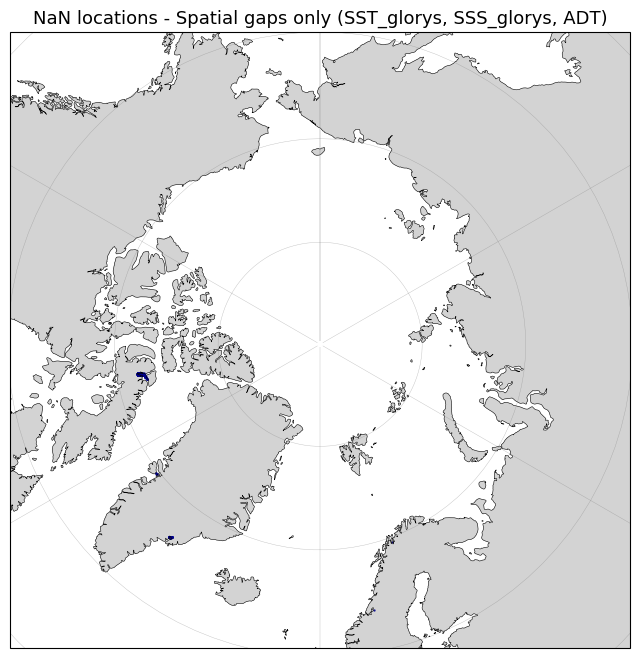

In [27]:
# Create figure with Arctic projection
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Plot profiles with NaN values (spatial gaps only, since time filtering was already done)
x_vals = ds_insitu['LONGITUDE'].values[nan_mask.values]
y_vals = ds_insitu['LATITUDE'].values[nan_mask.values]

# Limit to Arctic region
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

# Scatter colored by year 
sc = ax.scatter(
    x_vals,
    y_vals,
    #c=ds_insitu['TEMP'].isel(depth=0).values,
    s=0.5,
    c='darkblue', 
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

plt.title("NaN locations - Spatial gaps only (SST_glorys, SSS_glorys, ADT)", fontsize=13)
plt.show()
#plt.savefig("Insitu_profile_salinity.png", dpi=350)

In [28]:
# Rebuild ds_insitu dataset using the mask ~nan_mask_values
# Create new dataset with filtered profiles
nan_mask_values = nan_mask.values
clean_profile_indices = ~nan_mask_values

# Create new coordinates
new_profile_coord = np.arange(np.sum(clean_profile_indices))
depth_coord = ds_insitu.coords['depth']

# Initialize the clean dataset with coordinates
ds_clean = xr.Dataset(
    coords={
        'profile': new_profile_coord,
        'depth': depth_coord
    }
)

# Copy global attributes
ds_clean.attrs = dict(ds_insitu.attrs)

# Loop through all data variables and apply the mask
for var_name, var_data in ds_insitu.data_vars.items():
    if 'profile' in var_data.dims:
        # Apply mask to profile dimension
        filtered_values = var_data.values[clean_profile_indices]
        
        # Create new DataArray with filtered data
        ds_clean[var_name] = xr.DataArray(
            filtered_values,
            dims=var_data.dims,
            coords={dim: ds_clean.coords[dim] if dim in ds_clean.coords else var_data.coords[dim] 
                   for dim in var_data.dims},
            attrs=dict(var_data.attrs)
        )
    else:
        # Variable doesn't have profile dimension, copy as is
        ds_clean[var_name] = var_data.copy(deep=True)
        print(f"Copied variable without profile dimension: {var_name}")

print(f"Original profiles: {len(ds_insitu.profile)}")
print(f"Clean profiles (no NaNs): {len(ds_clean.profile)}")
print(f"Profiles removed: {len(ds_insitu.profile) - len(ds_clean.profile)}")

ds_clean

Original profiles: 188366
Clean profiles (no NaNs): 187276
Profiles removed: 1090


<xarray.Dataset> Size: 933MB
Dimensions:            (depth: 102, profile: 187276)
Coordinates:
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * profile            (profile) int64 1MB 0 1 2 3 ... 187273 187274 187275
Data variables: (12/17)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 153MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 153MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 153MB 0.0 0.0 10.11 ... 0.0 0.0
    ...                 ...
    lstm_training_QC   (profile) float64 1MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    X_EASE             (profile) float64 1MB -6.494e+05 2.643e+05 ... -4.477e+05
    Y_EASE             (profile) float64 1MB 1.122e+06 -1.324e+06 ... -2.104e+06
    SST_glorys         (profile) float64 1MB -1.596 -1.419 ... 7.092 1.584
    SSS_glorys         (profile) float64 1MB 29.97 34.56 34.5 ... 35.04 34.82
    ADT                (profile) float64 1MB 0.3588 -0.1985 ... -0.1731 -0.3381
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

In [29]:
print(f"insitu dataset size: {ds_insitu.nbytes / 1e9:.2f} GB")

insitu dataset size: 0.94 GB


-----------------------
-----------------------
PLOTS

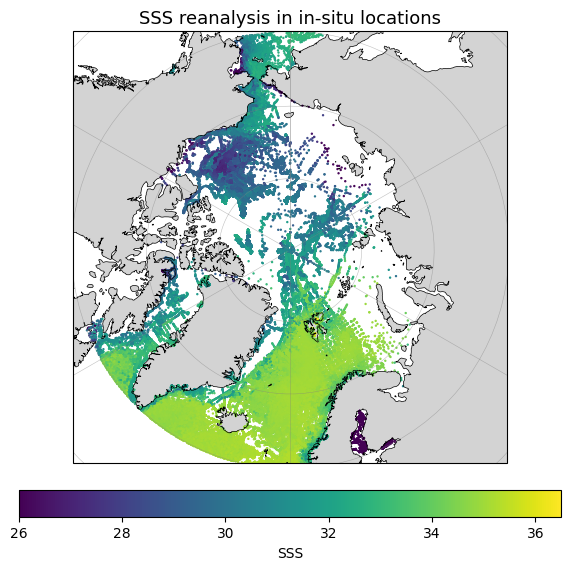

In [30]:
# Extract lat/lon
lats = ds_clean['LATITUDE'].values
lons = ds_clean['LONGITUDE'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5)


# Scatter colored by year 
sc = ax.scatter(
    lons, lats,
    c = ds_clean.SSS_glorys.values,
    s = 0.5,
    cmap ='viridis', 
    transform=ccrs.PlateCarree(), vmin=26, vmax=36.5  
)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('SSS')
plt.title("SSS reanalysis in in-situ locations", fontsize=13)
#plt.savefig(f'fresh_data/{maxdepth}m_in_situ_locations_sss.png', dpi=350)
plt.show()

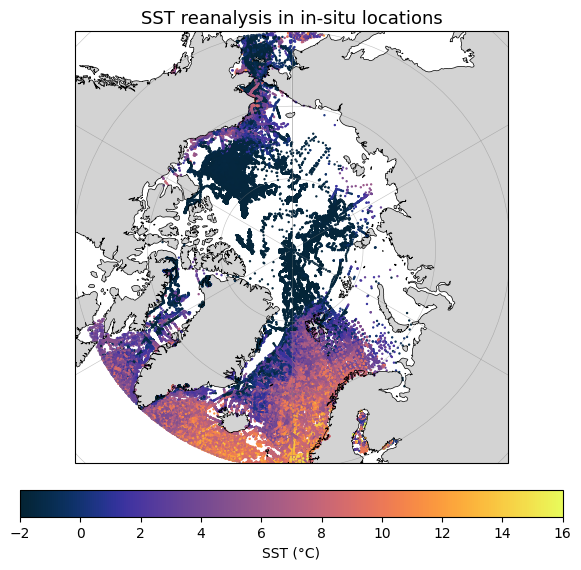

In [31]:
# Extract lat/lon
lats = ds_insitu['LATITUDE'].values
lons = ds_insitu['LONGITUDE'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5)


# Scatter colored by year 
sc = ax.scatter(
    lons, lats,
    c = ds_insitu.SST_glorys.values,
    s = 0.5,
    cmap ='cmo.thermal', 
    transform=ccrs.PlateCarree(),
    vmin=-2, vmax=16 
)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('SST (°C)')
plt.title("SST reanalysis in in-situ locations", fontsize=13)
#plt.savefig(f'fresh_data/{maxdepth}m_in_situ_locations_sst.png', dpi=350)
plt.show()

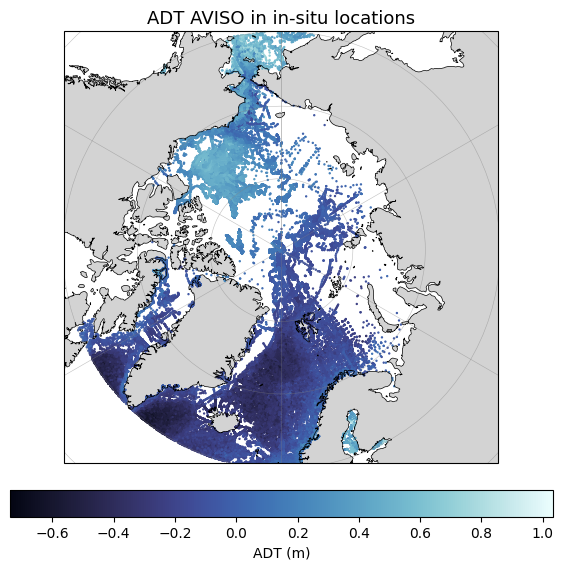

In [32]:
# Extract lat/lon
lats = ds_insitu['LATITUDE'].values
lons = ds_insitu['LONGITUDE'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5)


# Scatter colored by year 
sc = ax.scatter(
    lons, lats,
    c = ds_insitu.ADT.values,
    s = 0.5,
    cmap ='cmo.ice', 
    transform=ccrs.PlateCarree(),
)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('ADT (m)')
plt.title("ADT AVISO in in-situ locations", fontsize=13)
#plt.savefig(f'fresh_data/{maxdepth}m_in_situ_locations_adt.png', dpi=350)
plt.show()

LAST CHECK FOR NANS BEFORE SAVING

In [33]:
# Check for NaN values in ds_clean dataset
sss_nans_clean = ds_clean['SSS_glorys'].isnull().sum().compute()
sst_nans_clean = ds_clean['SST_glorys'].isnull().sum().compute()
adt_nans_clean = ds_clean['ADT'].isnull().sum().compute()

print(f"NaN values in ds_clean:")
print(f"SSS_glorys: {sss_nans_clean.item()}")
print(f"SST_glorys: {sst_nans_clean.item()}")
print(f"ADT: {adt_nans_clean.item()}")
print(f"Total NaNs: {(sss_nans_clean + sst_nans_clean + adt_nans_clean).item()}")

NaN values in ds_clean:
SSS_glorys: 0
SST_glorys: 0
ADT: 0
Total NaNs: 0


In [34]:
ds_clean

<xarray.Dataset> Size: 933MB
Dimensions:            (depth: 102, profile: 187276)
Coordinates:
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * profile            (profile) int64 1MB 0 1 2 3 ... 187273 187274 187275
Data variables: (12/17)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 153MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 153MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 153MB 0.0 0.0 10.11 ... 0.0 0.0
    ...                 ...
    lstm_training_QC   (profile) float64 1MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    X_EASE             (profile) float64 1MB -6.494e+05 2.643e+05 ... -4.477e+05
    Y_EASE             (profile) float64 1MB 1.122e+06 -1.324e+06 ... -2.104e+06
    SST_glorys         (profile) float64 1MB -1.596 -1.419 ... 7.092 1.584
    SSS_glorys         (profile) float64 1MB 29.97 34.56 34.5 ... 35.04 34.82
    ADT                (profile) float64 1MB 0.3588 -0.1985 ... -0.1731 -0.3381
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

SAVE THE DATASET

In [35]:
ds_clean.to_netcdf(out_path)